## Import libraries & clean up data


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
d = pd.read_csv('IRIS.csv')
d.shape

(150, 5)

In [3]:
d.isna().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [4]:
d.duplicated().sum()

np.int64(3)

In [5]:
d.drop_duplicates(inplace = True)
d.info()

<class 'pandas.DataFrame'>
Index: 147 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  147 non-null    float64
 1   sepal_width   147 non-null    float64
 2   petal_length  147 non-null    float64
 3   petal_width   147 non-null    float64
 4   species       147 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.9 KB


In [6]:
d.head(5)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


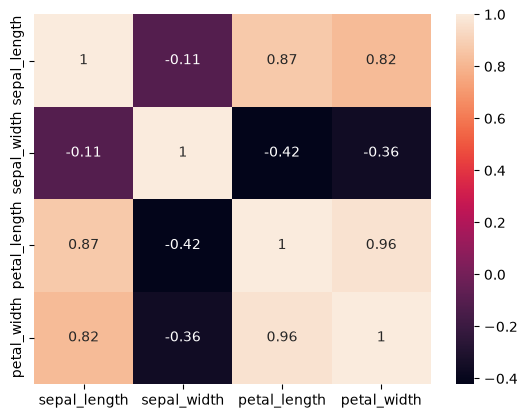

In [7]:
sns.heatmap(d.corr(numeric_only=True), annot=True)
plt.show()

## Training

In [8]:
x = d[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
y = d['species']

In [9]:
x_train , x_test, y_train , y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [10]:
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [11]:
lr = LinearRegression()
lr.fit(x_train , y_train)
pred = lr.predict(x_test)


In [12]:
print(r2_score(y_test, pred))
print(mean_squared_error(y_test, pred))

0.9171490867007299
0.05486571591818331


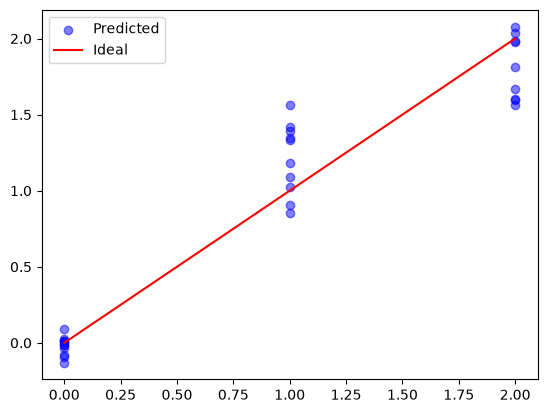

In [13]:
plt.scatter(y_test, pred, color='blue', alpha=0.5, label='Predicted')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], label='Ideal', color='red')
plt.legend()
plt.show()